<a href="https://colab.research.google.com/github/k-loaeza/dsrp/blob/main/projectkloaeza.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [19]:
!pip install pandas
!pip install matplotlib

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

import scipy.stats as stats
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# Exoplanets and the Search for Habitability

An exoplanet is a planet outside of our solar system. Out of the thousands of exoplanets identified, could some hold the key to life as we know it? How many planets are actually like Earth in size, distance to their host star, and physical characteristics? With over 6,000 confirmed exoplanets discovered to date, and thousands more candidates awaiting confirmation, the search for an Earth-like world has never been more active and data driven. What makes Earth uniquely suited for life comes down to a precise set of conditions scientists call the Goldilocks zone, which is the range of distances from a star, where the temperatures are neither too hot nor too cold for liquid water to exist. Earth sits at just the right distance from the Sun, is just the right size to hold an atmosphere, and maintains temperatures that allow life to thrive. Finding another planet that holds the same or similar conditions would be a significant discovery for humanity. This project invites students to use real NASA data to investigate that question.


In [2]:
url = 'https://raw.githubusercontent.com/frontiertechinstitute/datasets/refs/heads/main/NASA%20Exoplanet%20Data/nasa_exoplanets.csv'

data = pd.read_csv(url)
data.head()

,pl_name,hostname,pl_rade,pl_masse,pl_orbper,pl_orbsmax,pl_eqt,st_teff,st_rad,st_mass,discoverymethod,disc_year,sy_dist
0,Kepler-1167 b,Kepler-1167,1.710000,NaN,1.003934,0.01750,1419.0,4971.0,0.750,0.790,Transit,2016.0,820.905
1,Kepler-1740 b,Kepler-1740,3.323214,NaN,8.172400,0.07790,858.0,5705.0,0.905,0.943,Transit,2021.0,1061.770
2,Kepler-1581 b,Kepler-1581,0.800000,NaN,6.283855,0.06865,1108.0,6022.0,1.230,1.120,Transit,2016.0,493.175
3,Kepler-644 b,Kepler-644,3.150000,NaN,3.173917,0.04641,1655.0,6747.0,1.810,1.490,Transit,2016.0,1318.050
4,Kepler-1752 b,Kepler-1752,4.540605,NaN,56.358501,0.26980,419.0,5446.0,0.821,0.824,Transit,2021.0,962.888




*   pl_name = Exoplanet Name
*   host_name = Host Star
*   pl_rade = Radius of the exoplanet in units of Earth's radius
*   pl_masse = Mass of the exoplanet in units of Earth masses
*   pl_orbper = Orbital Period in Earth Days
*   pl_orbsmax = Longest radius of the elliptic orbit around the host star in AU
*   pl_eqt = The equilibrium temperature of the planet as modeled by a black body heated only by its host star, or for directly imaged planets, the effective temperature of the planet required to match the measured luminosity if the planet were a black body in Kelvin
*   st_teff = Temperature of the star as modeled by a black body emitting the same total amount of electromagnetic radiation in Kelvin
*   st_rad = Radius of the host star in units of Sun's radius
*   st_mass = Mass of the host star in units of Sun masses
*   discovery_method = The method through which the planet was identified first
*   disc_year = The year in which the planet was first identified
*   sy_dist = Distance to the planetary system in parsecs




In [3]:
data.info()
data.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6298 entries, 0 to 6297
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   pl_name          6298 non-null   object 
 1   hostname         6298 non-null   object 
 2   pl_rade          6248 non-null   float64
 3   pl_masse         2387 non-null   float64
 4   pl_orbper        5958 non-null   float64
 5   pl_orbsmax       5873 non-null   float64
 6   pl_eqt           4693 non-null   float64
 7   st_teff          6004 non-null   float64
 8   st_rad           5980 non-null   float64
 9   st_mass          6289 non-null   float64
 10  discoverymethod  6298 non-null   object 
 11  disc_year        6297 non-null   float64
 12  sy_dist          6271 non-null   float64
dtypes: float64(10), object(3)
memory usage: 639.8+ KB


,pl_rade,pl_masse,pl_orbper,pl_orbsmax,pl_eqt,st_teff,st_rad,st_mass,disc_year,sy_dist
count,6248.000000,2387.000000,5.958000e+03,5873.000000,4693.000000,6004.000000,5980.000000,6289.000000,6297.000000,6271.000000
mean,5.814146,807.870204,7.184593e+04,15.626989,914.662983,5392.629932,1.487920,0.933986,2017.190885,703.341417
std,5.407920,1585.552165,5.210495e+06,347.884017,462.876206,1731.489082,3.875038,0.387287,5.090143,1210.126435
min,0.309800,0.020000,9.070629e-02,0.004400,34.000000,415.000000,0.011500,0.009400,1992.000000,1.301190
25%,1.840000,11.115000,4.305389e+00,0.052300,569.000000,4897.000000,0.770000,0.770000,2014.000000,101.632000
50%,2.846633,156.053748,1.069293e+01,0.102200,823.000000,5542.000000,0.950000,0.940000,2016.000000,361.896000
75%,11.900000,722.348800,3.812277e+01,0.305000,1164.000000,5897.000000,1.240000,1.082000,2021.000000,824.499000
max,87.205870,9534.852210,4.020000e+08,19000.000000,4050.000000,57000.000000,88.475000,9.100000,2026.000000,8500.000000


In [4]:
# Standardizing column names
data.columns = ['pl_name', 'host_name', 'pl_rade', 'pl_masse', 'pl_orbper', 'pl_orbsmax',
       'pl_eqt', 'st_teff', 'st_rad', 'st_mass', 'disc_method',
       'disc_year', 'sy_dist']
data.head()
data[data['disc_year'].isnull()]
data['pl_name'].tail(10)
# Dropping rows with null values in disc year, sy dist, st mass,
dataD = data.dropna(subset=['disc_year', 'sy_dist', 'st_mass', 'pl_rade'])
data.info()
dataD.info()
data.isnull().sum()
dataD.isnull().sum()

dataD.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6298 entries, 0 to 6297
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   pl_name      6298 non-null   object 
 1   host_name    6298 non-null   object 
 2   pl_rade      6248 non-null   float64
 3   pl_masse     2387 non-null   float64
 4   pl_orbper    5958 non-null   float64
 5   pl_orbsmax   5873 non-null   float64
 6   pl_eqt       4693 non-null   float64
 7   st_teff      6004 non-null   float64
 8   st_rad       5980 non-null   float64
 9   st_mass      6289 non-null   float64
 10  disc_method  6298 non-null   object 
 11  disc_year    6297 non-null   float64
 12  sy_dist      6271 non-null   float64
dtypes: float64(10), object(3)
memory usage: 639.8+ KB
<class 'pandas.core.frame.DataFrame'>
Index: 6215 entries, 0 to 6297
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   pl_name      6215

,pl_rade,pl_masse,pl_orbper,pl_orbsmax,pl_eqt,st_teff,st_rad,st_mass,disc_year,sy_dist
count,6215.000000,2328.000000,5.889000e+03,5800.000000,4656.000000,5931.000000,5912.000000,6215.000000,6215.000000,6215.000000
mean,5.787122,763.616805,7.131367e+04,14.897215,913.641549,5382.902514,1.491860,0.934077,2017.200644,707.799408
std,5.297014,1537.255558,5.239902e+06,347.230105,460.558161,1648.277998,3.895043,0.372542,5.072420,1214.044999
min,0.309800,0.020000,1.120067e-01,0.005000,34.000000,575.000000,0.011500,0.009400,1992.000000,1.301190
25%,1.840000,10.900000,4.306557e+00,0.052235,569.000000,4898.000000,0.770000,0.770000,2014.000000,103.021000
50%,2.840000,143.022783,1.068758e+01,0.102000,823.000000,5545.000000,0.950000,0.940000,2016.000000,367.658000
75%,11.881540,654.750000,3.791000e+01,0.300625,1164.000000,5900.000000,1.241000,1.084200,2021.000000,828.592000
max,77.342100,9534.852210,4.020000e+08,19000.000000,4050.000000,57000.000000,88.475000,8.760000,2026.000000,8500.000000


Avoid working with the mass of the planet due to the missing values (so many)

Potential Research Questions:\
How does a planet's habitability relate to its distance from Earth?\
How does a planet's orbital period relate to its habitability?\
How does a planet's radius relate to its habitability?\
How do discovery methods relate to the discovery years?\
\* Habitability being defined as being as close to Earth values as possible \*\
Try making a regression that calculates whether or not a planet is likely to be habitable


In [5]:
data['sy_dist'].mean()
dataD['disc_method'].unique()

array(['Transit', 'Radial Velocity', 'Imaging', 'Microlensing',
       'Pulsar Timing', 'Transit Timing Variations',
       'Eclipse Timing Variations', 'Orbital Brightness Modulation',
       'Astrometry', 'Pulsation Timing Variations', 'Disk Kinematics'],
      dtype=object)

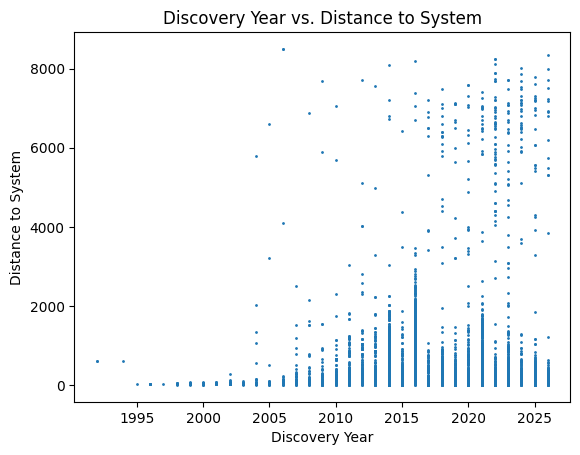

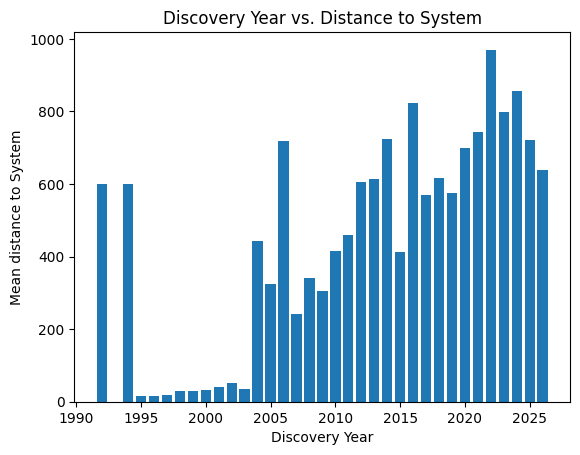

In [6]:
# Are closer exoplanets discovered earlier than more distant ones?
x = data['disc_year']
y = data['sy_dist']

plt.scatter(x, y, s=1)
plt.xlabel('Discovery Year')
plt.ylabel('Distance to System')
plt.title('Discovery Year vs. Distance to System')
plt.show()

# Plot that shows the mean distance of the exoplanets discovered per year
x = data['disc_year'].unique()
yy = []
for i in x:
  yy.append(data[data['disc_year'] == i]['sy_dist'].mean())
plt.bar(x, yy)
plt.xlabel('Discovery Year')
plt.ylabel('Mean distance to System')
plt.title('Discovery Year vs. Distance to System')
plt.show()

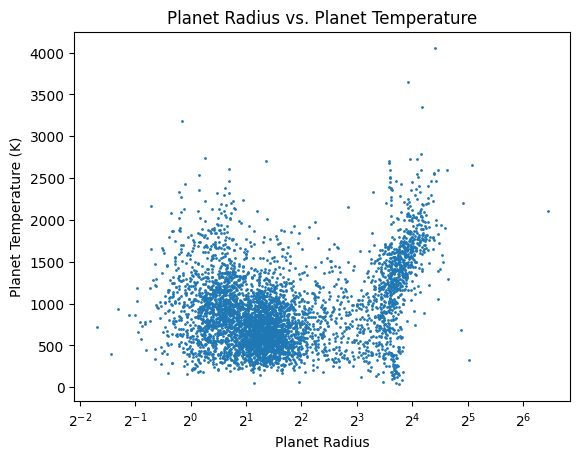

In [7]:
# Do larger planets tend to have higher temperatures?

x = data['pl_rade']
y = data['pl_eqt']

plt.scatter(x, y, s=1)
plt.xscale('log', base = 2)
plt.xlabel('Planet Radius')
plt.ylabel('Planet Temperature (K)')
plt.title('Planet Radius vs. Planet Temperature')
plt.show()

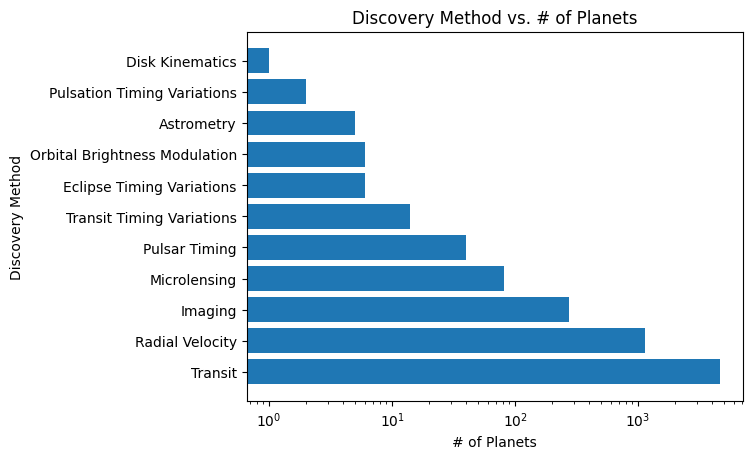

Text(0.5, 1.0, 'Discovery Method vs. # of Planets')

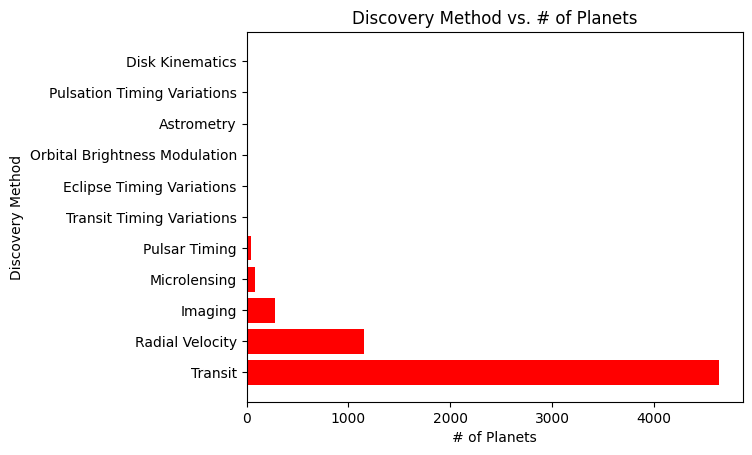

In [8]:
# Exoplanets discovered with every discovery method
x = dataD['disc_method'].unique()
y = dataD['disc_method'].value_counts()
plt.barh(x, y)
plt.xscale('log')
plt.xlabel('# of Planets')
plt.ylabel('Discovery Method')
plt.title('Discovery Method vs. # of Planets')
plt.show()

plt.barh(x, y, color= 'red')
plt.xlabel('# of Planets')
plt.ylabel('Discovery Method')
plt.title('Discovery Method vs. # of Planets')

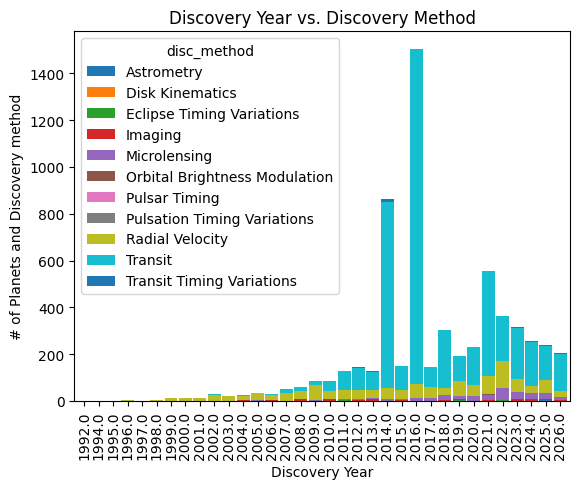

In [9]:
# How does the discovery method correlate with the discovery year?
yearMethod = pd.crosstab(dataD['disc_year'], dataD['disc_method'])
yearMethod.plot(kind='bar', stacked=True, width= 0.9)
plt.xlabel('Discovery Year')
plt.ylabel('# of Planets and Discovery method')
plt.title('Discovery Year vs. Discovery Method')
plt.show()

In [18]:
# Define thresholds for habitability, rough estimates based on research
# pl_radeT = 0.5 <= x <= 1.6
# pl_eqtT = 175 <= x <= 350
# pl_orbperT = 4.5 <= x <= 385

habdataD = dataD[(dataD['pl_rade'] >= 0.5) & (dataD['pl_rade'] <= 1.6) & (dataD['pl_eqt'] >= 175) & (dataD['pl_eqt'] <= 350)
                 & (dataD['pl_orbper'] >= 4.5) & (dataD['pl_orbper'] <= 385)]
habdataD['pot_habitable'] = True
habdataD.head()
habdataD.info()

habdataD['disc_method'].unique()


habdataD['disc_method'].value_counts()







<class 'pandas.core.frame.DataFrame'>
Index: 46 entries, 420 to 5927
Data columns (total 14 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   pl_name        46 non-null     object 
 1   host_name      46 non-null     object 
 2   pl_rade        46 non-null     float64
 3   pl_masse       12 non-null     float64
 4   pl_orbper      46 non-null     float64
 5   pl_orbsmax     46 non-null     float64
 6   pl_eqt         46 non-null     float64
 7   st_teff        46 non-null     float64
 8   st_rad         46 non-null     float64
 9   st_mass        46 non-null     float64
 10  disc_method    46 non-null     object 
 11  disc_year      46 non-null     float64
 12  sy_dist        46 non-null     float64
 13  pot_habitable  46 non-null     bool   
dtypes: bool(1), float64(10), object(3)
memory usage: 5.1+ KB


/tmp/ipykernel_30936/2496661059.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  habdataD['pot_habitable'] = True


,count
disc_method,
Transit,30
Radial Velocity,15
Transit Timing Variations,1


In [11]:
'''
# Step 1: Determine the brightness of the star:
teff_sun = 5778.0
dataD['luminosity'] = (dataD['st_rad']**2) * (dataD['st_teff'] / teff_sun)**4

# Step 2: Define habitable zone edges
dataD['hz_innerbound'] = np.sqrt(dataD['luminosity'] / 1.1)
dataD['hz_outerbound'] = np.sqrt(dataD['luminosity'] / 0.53)

# Step 3: Check if planet is in the habitable zone
dataD['in_hz'] = (dataD['pl_orbsmax'] >= dataD['hz_innerbound']) & (dataD['pl_orbsmax'] <= dataD['hz_outerbound'])

# Step 4: Check if planet is appropriately sized (filtering out gas giants)
dataD['is_rocky_size'] = (dataD['pl_rade'] >= 0.5) & (dataD['pl_rade'] <= 1.6)

# Step 5: Combine all criteria
dataD['pot_habitable'] = dataD['in_hz'] & dataD['is_rocky_size']

# Step 6: Write to the file
dataD.to_csv('habdataD.csv', index=False)

url = 'habdataD.csv'
habdataD = pd.read_csv(url)
habdataD.head()
habdataD['pot_habitable'].value_counts()
'''

"\n# Step 1: Determine the brightness of the star:\nteff_sun = 5778.0\ndataD['luminosity'] = (dataD['st_rad']**2) * (dataD['st_teff'] / teff_sun)**4\n\n# Step 2: Define habitable zone edges\ndataD['hz_innerbound'] = np.sqrt(dataD['luminosity'] / 1.1)\ndataD['hz_outerbound'] = np.sqrt(dataD['luminosity'] / 0.53)\n\n# Step 3: Check if planet is in the habitable zone\ndataD['in_hz'] = (dataD['pl_orbsmax'] >= dataD['hz_innerbound']) & (dataD['pl_orbsmax'] <= dataD['hz_outerbound'])\n\n# Step 4: Check if planet is appropriately sized (filtering out gas giants)\ndataD['is_rocky_size'] = (dataD['pl_rade'] >= 0.5) & (dataD['pl_rade'] <= 1.6)\n\n# Step 5: Combine all criteria\ndataD['pot_habitable'] = dataD['in_hz'] & dataD['is_rocky_size']\n\n# Step 6: Write to the file\ndataD.to_csv('habdataD.csv', index=False)\n\nurl = 'habdataD.csv'\nhabdataD = pd.read_csv(url)\nhabdataD.head()\nhabdataD['pot_habitable'].value_counts()\n"

In [12]:
# Modify original dataset so that it has a column that determines whether or not the planet is potentially habitable. based off entries in habdataD
# Initialize 'pot_habitable' column in dataD to False
dataD['pot_habitable'] = False
# Set 'pot_habitable' to True for rows that are in habdataD
dataD.loc[habdataD.index, 'pot_habitable'] = True

dataD['pot_habitable'].value_counts()

/tmp/ipykernel_30936/4264433356.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dataD['pot_habitable'] = False


,count
pot_habitable,
False,6169
True,46


In [13]:
dataD

,pl_name,host_name,pl_rade,pl_masse,pl_orbper,pl_orbsmax,pl_eqt,st_teff,st_rad,st_mass,disc_method,disc_year,sy_dist,pot_habitable
0,Kepler-1167 b,Kepler-1167,1.710000,NaN,1.003934e+00,0.01750,1419.0,4971.0,0.750,0.790,Transit,2016.0,820.9050,False
1,Kepler-1740 b,Kepler-1740,3.323214,NaN,8.172400e+00,0.07790,858.0,5705.0,0.905,0.943,Transit,2021.0,1061.7700,False
2,Kepler-1581 b,Kepler-1581,0.800000,NaN,6.283855e+00,0.06865,1108.0,6022.0,1.230,1.120,Transit,2016.0,493.1750,False
3,Kepler-644 b,Kepler-644,3.150000,NaN,3.173917e+00,0.04641,1655.0,6747.0,1.810,1.490,Transit,2016.0,1318.0500,False
4,Kepler-1752 b,Kepler-1752,4.540605,NaN,5.635850e+01,0.26980,419.0,5446.0,0.821,0.824,Transit,2021.0,962.8880,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6293,TOI-5624 f,TOI-5624,3.660000,NaN,4.537000e+01,0.23660,478.5,5327.0,0.820,0.858,Transit Timing Variations,2026.0,101.9130,False
6294,TOI-481 b,TOI-481,11.096910,486.279900,1.033111e+01,0.09700,1370.0,5735.0,1.660,1.140,Transit,2020.0,179.3660,False
6295,TOI-4336 A c,TOI-4336 A,1.251000,1.550000,7.587266e+00,0.05092,399.5,3307.0,0.326,0.306,Transit,2026.0,22.5455,False
6296,OGLE-2013-BLG-1761L b,OGLE-2013-BLG-1761L,13.200000,860.000000,NaN,1.80000,NaN,NaN,NaN,0.330,Microlensing,2017.0,6900.0000,False


In [24]:
# Hypothesis Test 1: The transit method discovers closer planets in comparison to the Radial velocity method
groups = habdataD.groupby('disc_method')['sy_dist']
transit = groups.get_group('Transit')
radial = groups.get_group('Radial Velocity')

result = stats.ttest_ind(transit, radial, alternative= 'less')
pval = result.pvalue
print(pval)

# p value of 0.99 indicates that we fail to reject the null hypothesis and both methods likely have no effect on
# the distance of the planets discovered



0.9998463637491242


In [29]:
# Hypothesis Test 2: Exoplanets that are not potentially habitable orbit larger stars in comparison to potentially habitable exoplanets.
hab_sizes = dataD.loc[dataD['pot_habitable'] == True, 'st_rad']
nonhab_sizes = dataD.loc[dataD['pot_habitable'] == False, 'st_rad']

print("Potentially Habitable n, mean:", len(hab_sizes), hab_sizes.mean())
print("Not Potentially Habitable n, mean:", len(nonhab_sizes), nonhab_sizes.mean())

# Check for null values
print("NaNs in hab_sizes:", hab_sizes.isnull().sum())
print("NaNs in nonhab_sizes:", nonhab_sizes.isnull().sum())

# Drop nulls to prevent ttest errors
hab_sizes = hab_sizes.dropna()
nonhab_sizes = nonhab_sizes.dropna()

# Check standard deviations
print("Std Dev of hab_sizes:", hab_sizes.std())
print("Std Dev of nonhab_sizes:", nonhab_sizes.std())

# Calculate p value

result = stats.ttest_ind(nonhab_sizes, hab_sizes, alternative= 'greater')
pval = result.pvalue
print(pval)

# Non habitable exoplanets typically orbit larger stars in comparison to potentially habitable exoplanets. With a
# p value < 0.05, we can reject the null hypothesis

Potentially Habitable n, mean: 46 0.3642665652173913
Not Potentially Habitable n, mean: 6169 1.5007028111148994
NaNs in hab_sizes: 0
NaNs in nonhab_sizes: 303
Std Dev of hab_sizes: 0.20322762189893295
Std Dev of nonhab_sizes: 3.9089618090033285
0.024350201945093564
